In [ ]:
!pip install yfinance

Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

print("Libraries imported successfully!")

Libraries imported successfully!


Upload the Dataset

In [3]:
from google.colab import files

uploaded = files.upload()

Saving stock_price_dataset.csv to stock_price_dataset.csv


Load the Dataset

In [4]:
import pandas as pd

df = pd.read_csv("stock_price_dataset.csv")

print("Dataset loaded successfully!")
print("\nFirst 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

Dataset loaded successfully!

First 5 rows:
         Date    Open    High     Low   Close  Volume
0  2024-01-01  100.41  100.64   98.58  100.00   46875
1  2024-01-02  100.44  102.06  100.17  100.68   41982
2  2024-01-03  100.72  101.08   99.69  100.59   43328
3  2024-01-04  101.45  102.40  100.33  101.45   22329
4  2024-01-05  103.41  103.97  102.02  103.36   35169

Dataset shape:
(365, 6)

Column names:
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')


Select the closing price

In [5]:

data = df[['Close']].values

print("Close price data:")
print(data[:5])

print("\nNumber of records:", len(data))

Close price data:
[[100.  ]
 [100.68]
 [100.59]
 [101.45]
 [103.36]]

Number of records: 365


Visualize Stock Closing Prices

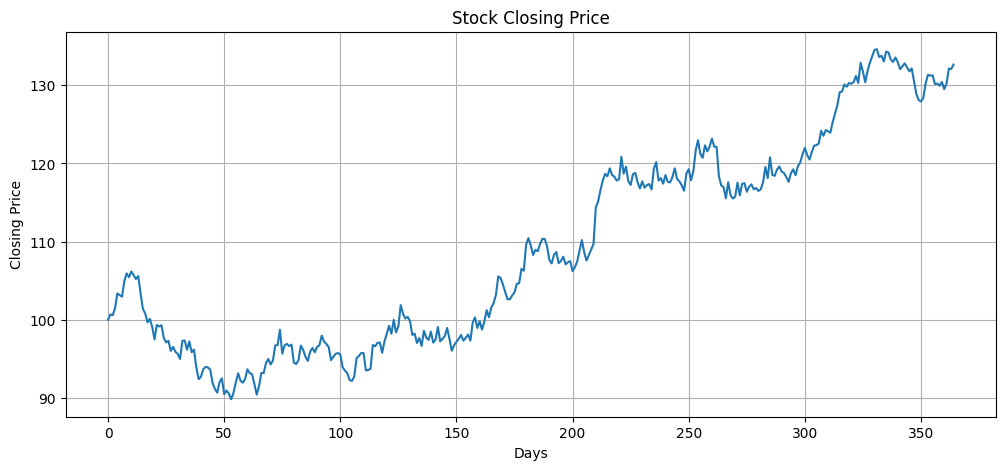

In [6]:
plt.figure(figsize=(12, 5))

plt.plot(data)

plt.title("Stock Closing Price")
plt.xlabel("Days")
plt.ylabel("Closing Price")
plt.grid(True)

plt.show()

Normalize the Data

In [7]:
scaler = MinMaxScaler(feature_range=(0, 1))

scaled_data = scaler.fit_transform(data)

print("Original data:")
print(data[:5])

print("\nScaled data:")
print(scaled_data[:5])

Original data:
[[100.  ]
 [100.68]
 [100.59]
 [101.45]
 [103.36]]

Scaled data:
[[0.22705961]
 [0.24224157]
 [0.24023219]
 [0.25943291]
 [0.30207636]]


Create Time-Series Sequences

In [8]:
time_step = 60

X = []
y = []

for i in range(time_step, len(scaled_data)):
    X.append(scaled_data[i-time_step:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (305, 60)
y shape: (305,)


Split Data into Training and Testing Sets

In [9]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Training data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training data:
X_train: (244, 60)
y_train: (244,)

Testing data:
X_test: (61, 60)
y_test: (61,)


Reshape Data for LSTM

In [10]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (244, 60, 1)
X_test shape: (61, 60, 1)


Build the LSTM Model

In [11]:
model = Sequential()

model.add(LSTM(50, return_sequences=True,
               input_shape=(X_train.shape[1], 1)))

model.add(LSTM(50))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

Train the LSTM Model

In [12]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 137ms/step - loss: 0.1039 - val_loss: 0.0192
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0186 - val_loss: 7.9187e-04
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0101 - val_loss: 0.0302
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0088 - val_loss: 0.0014
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0059 - val_loss: 0.0010
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0041 - val_loss: 0.0040
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0037 - val_loss: 7.0496e-04
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0033 - val_loss: 7.1796e-04
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - loss: 0.0033 - val_loss: 0.0010
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - loss: 0.0031 - val_loss: 8.2650e-04
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - loss: 0.0031 - val_loss: 8.8528e-04
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 0.00

Plot Training and Validation Loss

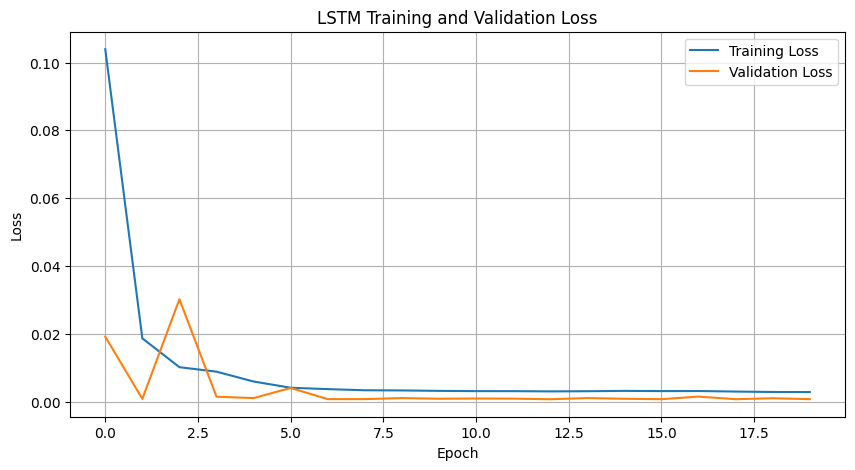

In [13]:
plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

Predict Stock Prices

In [14]:
predicted = model.predict(X_test)

print("Prediction completed!")
print("Predicted data shape:", predicted.shape)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 360ms/step
Prediction completed!
Predicted data shape: (61, 1)


Convert Predictions Back to Original Prices

In [15]:
predicted_prices = scaler.inverse_transform(predicted)
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

print("Predicted prices:")
print(predicted_prices[:5])

print("\nActual prices:")
print(actual_prices[:5])

Predicted prices:
[[120.25897 ]
 [120.462616]
 [120.67513 ]
 [120.89328 ]
 [121.160034]]

Actual prices:
[[122.28]
 [122.34]
 [122.56]
 [124.17]
 [123.54]]


Calculate MAE and RMSE

In [16]:
mae = mean_absolute_error(actual_prices, predicted_prices)

rmse = np.sqrt(
    mean_squared_error(actual_prices, predicted_prices)
)

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 3.061407145515817
Root Mean Squared Error (RMSE): 3.4349718509725693


Actual vs Predicted Stock Prices

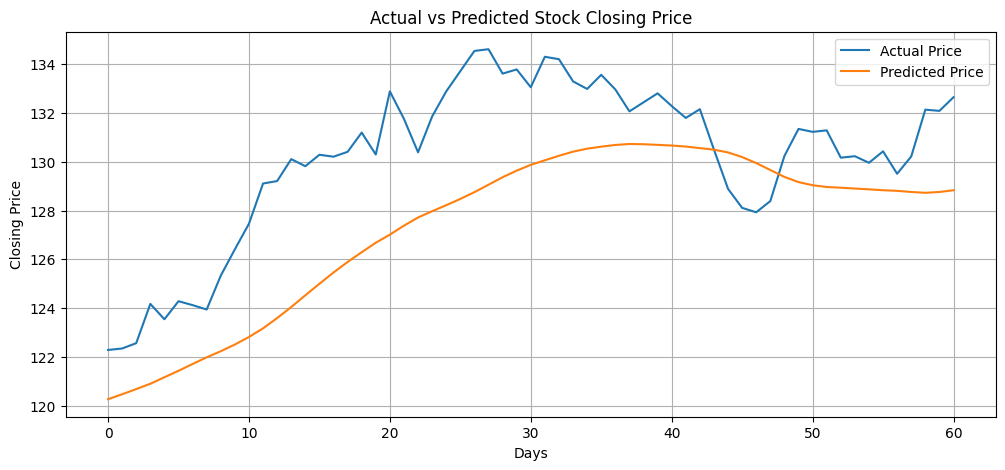

In [17]:
plt.figure(figsize=(12, 5))

plt.plot(actual_prices, label="Actual Price")
plt.plot(predicted_prices, label="Predicted Price")

plt.title("Actual vs Predicted Stock Closing Price")
plt.xlabel("Days")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)

plt.show()